In [1]:
from pathlib import Path
import kagglehub
import os

# Download latest version
path = Path(kagglehub.dataset_download("sagyamthapa/handwritten-math-symbols"))
path = path / "dataset"
print("Path to dataset files:", path)

path2 = Path(kagglehub.dataset_download("aditya126/basic-maths-symbols-dataset"))
path2 = path2 / "symbol_dataset"

target_symbol = "open_bracket"
for i in range(2):
    if i == 1:
        target_symbol = "close_bracket"

    target_dir = path / target_symbol
    target_dir.mkdir(parents=True, exist_ok=True)

    source_dir = path2 / target_symbol

    files = sorted(source_dir.glob("*.png"))[:500]
    for file_path in files:
        file = target_dir / file_path.name
        file.write_bytes(file_path.read_bytes())

    print("done copying images ", target_symbol)


C:\Users\Alex\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Alex\.cache\kagglehub\datasets\sagyamthapa\handwritten-math-symbols\versions\4\dataset
done copying images  open_bracket
done copying images  close_bracket


In [2]:
for dirpath, dirnames, filenames in os.walk(path):
    print(f"path: {dirpath}, directories: {len(dirnames)}, files: {len(filenames)}")

path: C:\Users\Alex\.cache\kagglehub\datasets\sagyamthapa\handwritten-math-symbols\versions\4\dataset, directories: 21, files: 1
path: C:\Users\Alex\.cache\kagglehub\datasets\sagyamthapa\handwritten-math-symbols\versions\4\dataset\0, directories: 0, files: 595
path: C:\Users\Alex\.cache\kagglehub\datasets\sagyamthapa\handwritten-math-symbols\versions\4\dataset\1, directories: 0, files: 562
path: C:\Users\Alex\.cache\kagglehub\datasets\sagyamthapa\handwritten-math-symbols\versions\4\dataset\2, directories: 0, files: 433
path: C:\Users\Alex\.cache\kagglehub\datasets\sagyamthapa\handwritten-math-symbols\versions\4\dataset\3, directories: 0, files: 541
path: C:\Users\Alex\.cache\kagglehub\datasets\sagyamthapa\handwritten-math-symbols\versions\4\dataset\4, directories: 0, files: 526
path: C:\Users\Alex\.cache\kagglehub\datasets\sagyamthapa\handwritten-math-symbols\versions\4\dataset\5, directories: 0, files: 433
path: C:\Users\Alex\.cache\kagglehub\datasets\sagyamthapa\handwritten-math-symb

In [3]:
import torch
from PIL import ImageOps
from torchvision import datasets, transforms
from torchvision.transforms.functional import invert
from torch.utils.data import random_split, DataLoader
 
torch.manual_seed(42)

def pad_to_square(img):
    w, h = img.size
    size = max(w, h)
    return ImageOps.pad(img, (size, size), color=255, centering=(0.5, 0.5))
 
 
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    # transforms.Lambda(pad_to_square),
    transforms.Resize((32, 32)),
    transforms.RandomRotation(12),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), shear=4),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: 1.0 - x),
    transforms.Normalize((0.5,), (0.5,))
])

brackets_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((32, 32)),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), shear=4),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x > 0.5).float()),
    transforms.Normalize((0.5,), (0.5,))
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((32, 32)),
    transforms.GaussianBlur(kernel_size=(3, 3), sigma=(0.5, 0.5)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: 1.0 - x),
    transforms.Normalize((0.5,), (0.5,))
])

In [4]:
# 80% train & 20% test slice

from torch.utils.data import Subset, ConcatDataset

normal_ds = datasets.ImageFolder(root=path, transform=train_transform)
brackets_ds = datasets.ImageFolder(root=path, transform=brackets_transform)

#merge different bracket & normal dataset transformations
bracket_ids = {normal_ds.class_to_idx['open_bracket'], normal_ds.class_to_idx['close_bracket']}
is_bracket = [label in bracket_ids for _, label in normal_ds.samples]

train_items = Subset(normal_ds, [i for i, b in enumerate(is_bracket) if not b])
bracket_items = Subset(brackets_ds, [i for i, b in enumerate(is_bracket) if b])

def split_items(items, train_ratio=0.8, seed=42):
    train_size = int(train_ratio * len(items))
    test_size = len(items) - train_size
    return random_split(items, [train_size, test_size], generator=torch.Generator().manual_seed(seed))

normal_train_idx, normal_test_idx = split_items(train_items)
bracket_train_idx, bracket_test_idx = split_items(bracket_items)

train_dataset = ConcatDataset([
    normal_ds, normal_train_idx,
    brackets_ds, bracket_train_idx
])

test_dataset = ConcatDataset([
    normal_ds, normal_test_idx,
    brackets_ds, bracket_test_idx
])


loaders = {
    "train": DataLoader(train_dataset, batch_size=32, shuffle=True),
    "test": DataLoader(test_dataset, batch_size=32, shuffle=False)
}

In [5]:
import torch.nn as nn
import torch.nn.functional as F



class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += residual
        return F.relu(out)


class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1) #change to 1, 32 later
        self.bn1 = nn.BatchNorm2d(32)
        self.res1 = ResidualBlock(32)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) #32, 64
        self.bn2 = nn.BatchNorm2d(64)
        self.res2 = ResidualBlock(64)
        
        self.pool = nn.MaxPool2d(2, 2)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        
        self.dropout_spatial = nn.Dropout2d(0.1)
        self.dropout_dense = nn.Dropout(0.3)
        
        self.fc1 = nn.Linear(64 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, 21)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.res1(x)
        x = self.dropout_spatial(x)

        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.res2(x)

        x = self.adaptive_pool(x)
        x = torch.flatten(x, 1)
        
        x = F.relu(self.fc1(x))
        x = self.dropout_dense(x)
        x = self.fc2(x)
        
        return x

In [6]:
import torch
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = CNN().to(device)

optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=2,
    factor=0.5
)

loss_fn = nn.CrossEntropyLoss(label_smoothing=0.05)


def train(epoch):
    model.train()
    running_loss = 0.00
    
    for batch_idx, (data, target) in enumerate(loaders['train']):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = loss_fn(output, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        
        if batch_idx % 20 == 0:
            print(f"Train Epoch: {epoch} [{batch_idx * len(data)}/{len(loaders['train'].dataset)} "
                  f"({100. * batch_idx / len(loaders['train']):.0f}%)]\tLoss: {loss.item():.6f}")
    
    print(f"EPOCH {epoch} Complete. Average Train Loss: {running_loss / len(loaders['train']):.4f}")


predictions = []
targets = []

def test(final=False):
    model.eval()
    test_loss = 0
    correct = 0 

    with torch.no_grad():
        for data, target in loaders['test']:
            data, target = data.to(device), target.to(device)
            output = model(data)

            test_loss += loss_fn(output, target).item()
            pred = output.data.max(1, keepdim=True)[1]
            correct += pred.eq(target.data.view_as(pred)).sum().item()

            if final:
                predictions.extend(pred.squeeze().cpu().numpy())
                targets.extend(target.cpu().numpy())

        test_loss /= len(loaders['test'])
        accuracy = 100. * correct / len(loaders['test'].dataset)
        scheduler.step(test_loss)
        
        print(f"TEST: Average Loss: {test_loss:.4f} | Total Accuracy: {correct}/{len(loaders['test'].dataset)} ({accuracy:.2f}%)\n")

In [7]:
epochs = 16

for epoch in range(1, epochs+1):
    train(epoch)
    if epoch == epochs:
        test(True)
    else:
        test()

Train Epoch: 1 [0/30998 (0%)]	Loss: 3.112988
Train Epoch: 1 [640/30998 (2%)]	Loss: 3.040842
Train Epoch: 1 [1280/30998 (4%)]	Loss: 2.915352
Train Epoch: 1 [1920/30998 (6%)]	Loss: 2.427538
Train Epoch: 1 [2560/30998 (8%)]	Loss: 2.152146
Train Epoch: 1 [3200/30998 (10%)]	Loss: 2.012213
Train Epoch: 1 [3840/30998 (12%)]	Loss: 2.057528
Train Epoch: 1 [4480/30998 (14%)]	Loss: 1.811864
Train Epoch: 1 [5120/30998 (17%)]	Loss: 1.687182
Train Epoch: 1 [5760/30998 (19%)]	Loss: 1.581958
Train Epoch: 1 [6400/30998 (21%)]	Loss: 1.610663
Train Epoch: 1 [7040/30998 (23%)]	Loss: 1.300455
Train Epoch: 1 [7680/30998 (25%)]	Loss: 1.414713
Train Epoch: 1 [8320/30998 (27%)]	Loss: 1.368485
Train Epoch: 1 [8960/30998 (29%)]	Loss: 1.262961
Train Epoch: 1 [9600/30998 (31%)]	Loss: 1.148946
Train Epoch: 1 [10240/30998 (33%)]	Loss: 1.035392
Train Epoch: 1 [10880/30998 (35%)]	Loss: 1.261836
Train Epoch: 1 [11520/30998 (37%)]	Loss: 1.490467
Train Epoch: 1 [12160/30998 (39%)]	Loss: 1.132920
Train Epoch: 1 [12800/309

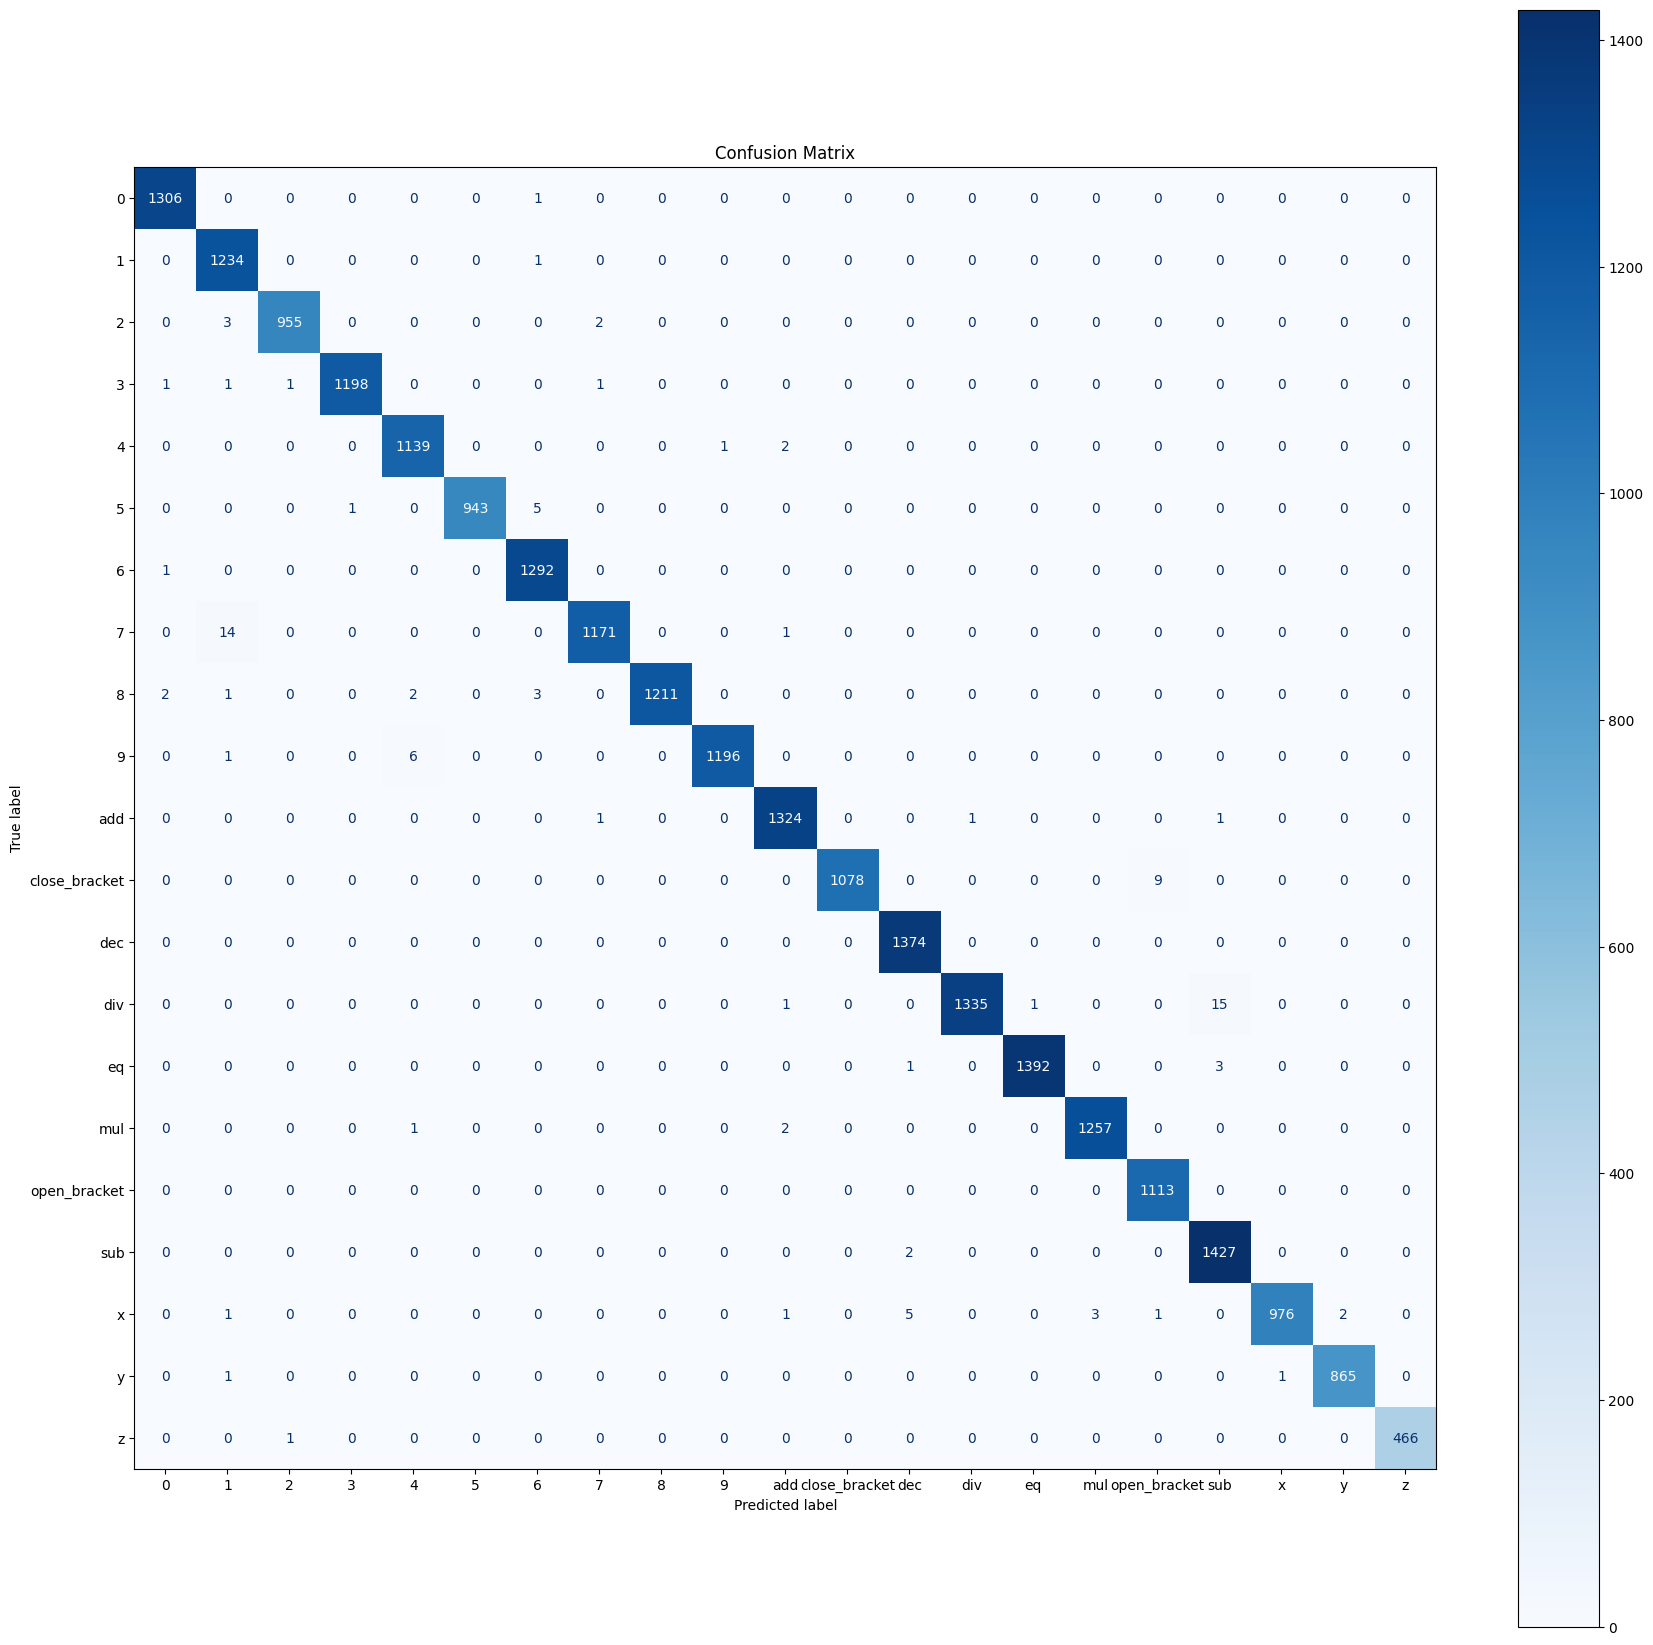

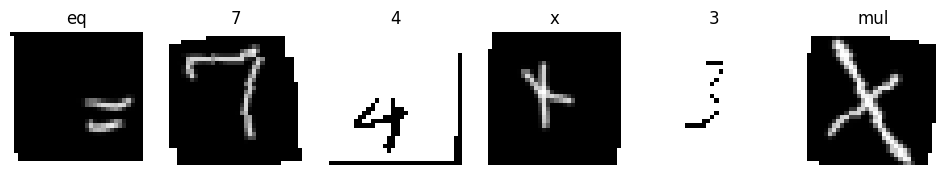

True Class: close_bracket
Predicted Class: close_bracket
Raw Logits: [-1.8897827 -1.2256943 -2.181834  -2.1321492 -2.6761563 -1.73861
 -2.1475618 -1.8975563 -2.383758  -2.2530386 -1.4502057  4.1756406
 -2.0634093 -2.173207  -2.2452009 -1.7087115  0.3720572 -2.1546948
 -1.7644695 -2.5162632 -1.8664932]


In [8]:
# confusion matrix

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(targets, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=normal_ds.classes)

fig, ax = plt.subplots(figsize=(21, 21))
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


import matplotlib.pyplot as plt

images, labels = next(iter(loaders['train']))

fig, axes = plt.subplots(1, 6, figsize=(12, 3))
for i in range(6):
    # Un-normalize from [-1, 1] back to [0, 1] for visualization
    img = images[i][0] * 0.5 + 0.5 
    axes[i].imshow(img.numpy(), cmap='gray')
    axes[i].set_title(normal_ds.classes[labels[i]])
    axes[i].axis('off')
plt.show()


model.eval()
with torch.no_grad():
    # Pass a single bracket sample
    sample_img, sample_label = bracket_items[0]
    output = model(sample_img.unsqueeze(0))
    pred_idx = torch.argmax(output, dim=1).item()
    
    print(f"True Class: {normal_ds.classes[sample_label]}")
    print(f"Predicted Class: {normal_ds.classes[pred_idx]}")
    print(f"Raw Logits: {output.squeeze().numpy()}")

In [9]:
import torch
import onnx
from huggingface_hub import HfApi

# 1. Export
dummy_input = torch.randn(1, 1, 32, 32).to(device)
torch.onnx.export(
    model,
    dummy_input,
    "cnn_single.onnx",
    dynamo=True,
    input_names=["input"],
    output_names=["output"],
)

# 2. Merge into single file
model_proto = onnx.load("cnn_single.onnx")
onnx.save(model_proto, "cnn_single.onnx", save_as_external_data=False)

# 3. Upload to Hugging Face
api = HfApi()
api.upload_file(
    path_or_fileobj="cnn_single.onnx",
    path_in_repo="cnn_single.onnx",
    repo_id="booogiee/math_cnn",
    repo_type="model"
)

print("Done!")

[torch.onnx] Obtain model graph for `CNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `CNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


C:\Users\Alex\AppData\Local\Programs\Python\Python313\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


 ... (more hidden) ...


Done!
